# JIE32803 Machine Learning - Individual Task (Part A)
# Name: Mariah binti Halim (S23B0106)
# Model: Gaussian Naive Bayes
# Dataset: Breast Cancer Wisconsin (Diagnostic) - data.csv
# Task type: Binary Classification (diagnosis: M = Malignant, B = Benign)

1. Upload dataset

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
uciml_breast_cancer_wisconsin_data_path = kagglehub.dataset_download('uciml/breast-cancer-wisconsin-data')

print('Data source import complete.')


Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Data source import complete.


2. Import libraries

In [ ]:
# Import necessary libraries for data analysis, preprocessing, model building, and evaluation.
# pandas for data manipulation (DataFrames).
# numpy for numerical array operations.
# matplotlib.pyplot and seaborn for data visualization.
# sklearn.model_selection for splitting data and cross-validation.
# sklearn.preprocessing for feature scaling and label encoding.
# sklearn.naive_bayes for the Gaussian Naive Bayes model.
# sklearn.metrics for calculating and reporting model performance metrics.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

3. Problem Framing & Data Exploration

Shape of dataset: (569, 33)

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_wor

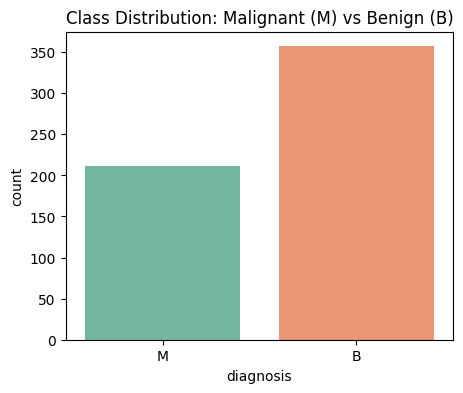

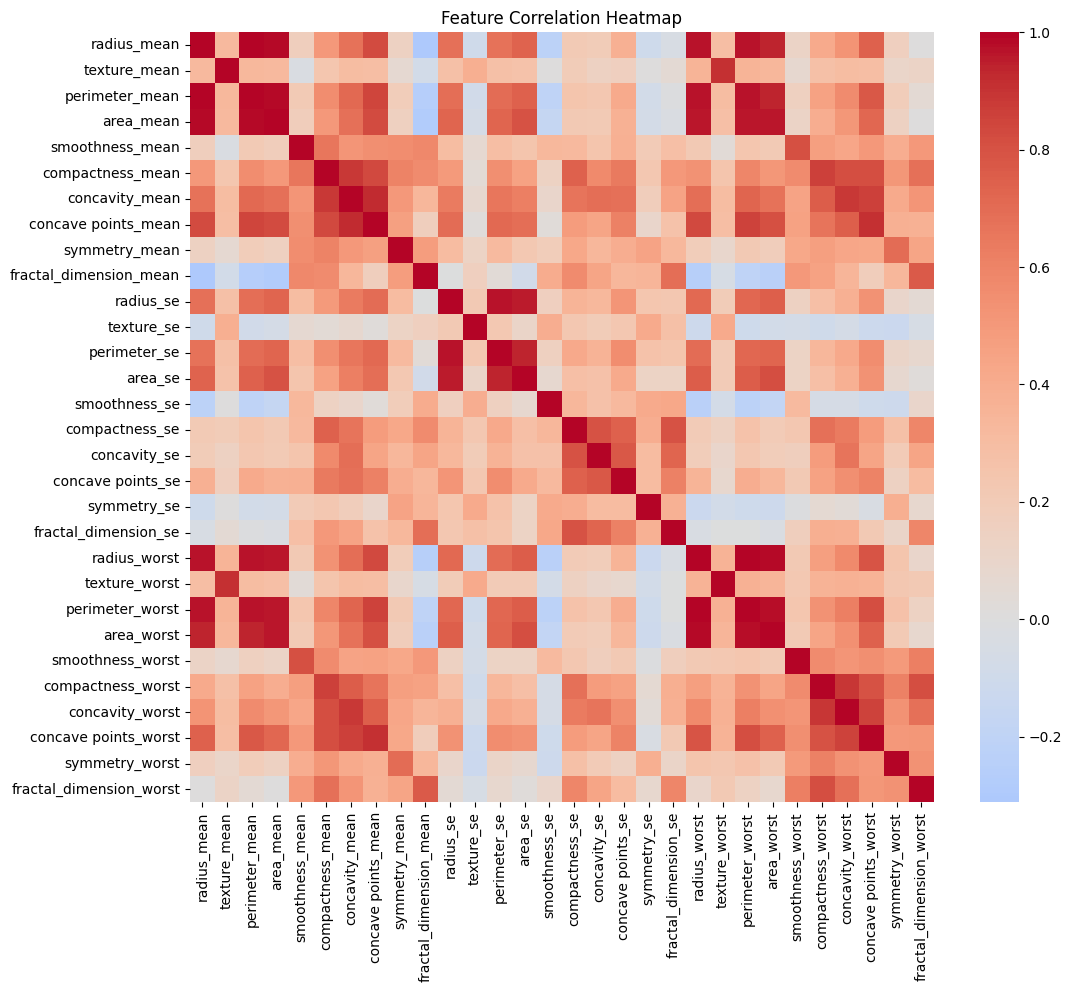

In [ ]:
# Read the 'data.csv' dataset into a pandas DataFrame.
df = pd.read_csv(f"{uciml_breast_cancer_wisconsin_data_path}/data.csv")

# Print the shape of the dataset (number of rows, number of columns).
print("Shape of dataset:", df.shape)
# Print the first 5 rows of the dataset for an initial overview.
print("\nFirst 5 rows:")
print(df.head())

# Print a concise summary of the DataFrame, including data types and non-null values.
print("\nColumn info:")
print(df.info())

# Check for missing (null) values in each column.
print("\nMissing values per column:")
print(df.isnull().sum())

# Drop the 'id' column (not useful for prediction) and any empty 'Unnamed' columns.
df = df.drop(columns=[c for c in df.columns if "Unnamed" in c or c == "id"], errors="ignore")

# Print the distribution of classes for the 'diagnosis' column.
print("\nClass distribution (diagnosis):")
print(df["diagnosis"].value_counts())
# Print the class distribution as percentages.
print(df["diagnosis"].value_counts(normalize=True) * 100)

# Visualize the class balance using a countplot.
plt.figure(figsize=(5,4))
sns.countplot(x="diagnosis", data=df, hue="diagnosis", palette="Set2", legend=False)
plt.title("Class Distribution: Malignant (M) vs Benign (B)")
plt.show()

# Generate a correlation heatmap to understand relationships between features.
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns=["diagnosis"]).corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

4. Data Preparation - Encode target & split features

In [ ]:
# Encode the target variable 'diagnosis': 'M' (malignant) to 1, 'B' (benign) to 0.
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # M=1, B=0
# Print the encoding mapping for reference.
print("\nEncoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Separate features (X) and the target variable (y).
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Perform Feature Scaling (Standardization) using StandardScaler.
# This is beneficial for many ML algorithms and helps when comparing models.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split the data into training (70%) and testing (30%) sets, stratified to maintain class balance.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Print the sizes of the training and testing sets.
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Encoding mapping: {'B': np.int64(0), 'M': np.int64(1)}

Training set size: (398, 30)
Testing set size: (171, 30)


5. Model implementation - Gaussian Naive Bayes

In [ ]:
# Initialize the Gaussian Naive Bayes model.
nb_model = GaussianNB()
# Train the model using the training set.
nb_model.fit(X_train, y_train)

# Make class predictions on the test set.
y_pred = nb_model.predict(X_test)
# Calculate predicted probabilities for the 'malignant' class (class 1).
y_proba = nb_model.predict_proba(X_test)[:, 1]  # probability of malignant

# Perform 5-fold Cross-Validation to assess model stability and generalization.
cv_scores = cross_val_score(nb_model, X_scaled, y, cv=5, scoring="accuracy")
print("Cross-validation accuracy scores:", cv_scores)
# Print the mean cross-validation accuracy and its standard deviation.
print("Mean CV accuracy: %.4f (+/- %.4f)" % (cv_scores.mean(), cv_scores.std()))

Cross-validation accuracy scores: [0.90350877 0.9122807  0.95614035 0.94736842 0.92035398]
Mean CV accuracy: 0.9279 (+/- 0.0204)


6. Model Evaluation - Metrics

In [ ]:
# Calculate various performance metrics for the Naive Bayes model.
# Accuracy: Proportion of correctly classified instances.
acc = accuracy_score(y_test, y_pred)
# Precision: Proportion of true positive predictions among all positive predictions.
prec = precision_score(y_test, y_pred)
# Recall: Proportion of true positive instances that were correctly identified.
rec = recall_score(y_test, y_pred)
# F1-score: Harmonic mean of precision and recall.
f1 = f1_score(y_test, y_pred)
# AUC (Area Under the Receiver Operating Characteristic Curve): Measures the model's ability to distinguish between classes.
auc = roc_auc_score(y_test, y_proba)

# Print the key performance metrics.
print("===== Naive Bayes Performance on Test Set ====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

# Print a full classification report, providing precision, recall, f1-score, and support for each class.
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=["Benign (B)", "Malignant (M)"]))

===== Naive Bayes Performance on Test Set ====
Accuracy : 0.9357
Precision: 0.9492
Recall   : 0.8750
F1-score : 0.9106
AUC      : 0.9933

Full classification report:
               precision    recall  f1-score   support

   Benign (B)       0.93      0.97      0.95       107
Malignant (M)       0.95      0.88      0.91        64

     accuracy                           0.94       171
    macro avg       0.94      0.92      0.93       171
 weighted avg       0.94      0.94      0.94       171



7. Confusion Matrix

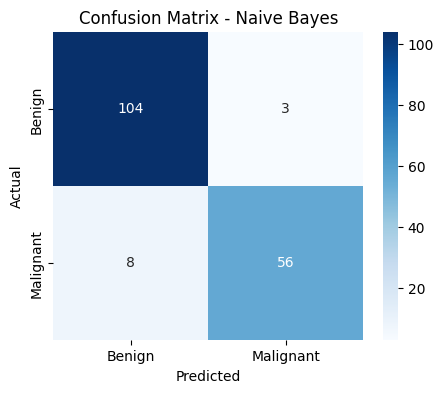

In [ ]:
# Calculate the confusion matrix.
# This matrix shows the counts of true positives, true negatives, false positives, and false negatives.
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a seaborn heatmap for better readability.
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

8. ROC Curve

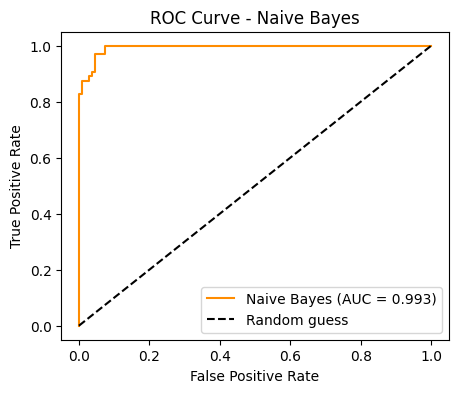

In [ ]:
# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve.
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Visualize the ROC (Receiver Operating Characteristic) curve.
plt.figure(figsize=(5,4))
# Plot the ROC curve for the Naive Bayes model.
plt.plot(fpr, tpr, label=f"Naive Bayes (AUC = {auc:.3f})", color="darkorange")
# Plot a dashed diagonal line representing a random guess (AUC = 0.5).
plt.plot([0,1],[0,1],"k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.show()

9. Model Comparison


===== Model Comparison ====
              Model  Accuracy  Precision   Recall  F1-score
Logistic Regression  0.970760   0.983607 0.937500  0.960000
      Random Forest  0.970760   1.000000 0.921875  0.959350
        Naive Bayes  0.935673   0.949153 0.875000  0.910569
      Decision Tree  0.900585   0.885246 0.843750  0.864000


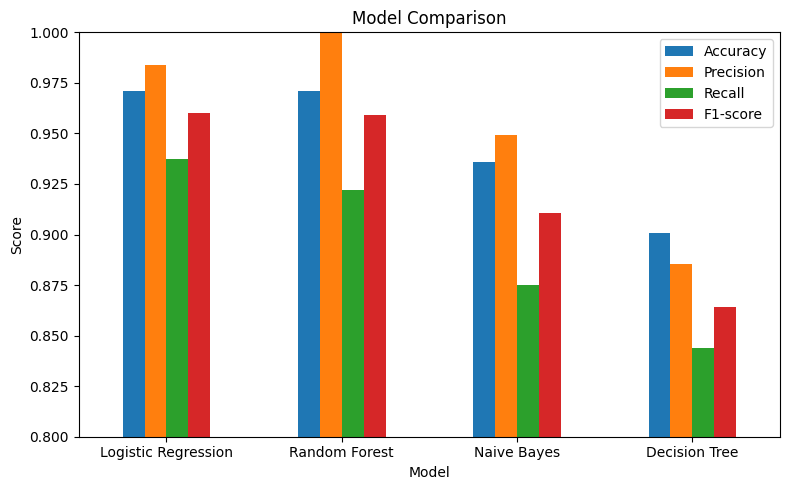

In [ ]:
# Import additional classification models for comparative analysis.
# Logistic Regression: A linear model for binary classification.
# Decision Tree: A tree-based model that makes decisions sequentially.
# RandomForestClassifier: An ensemble model that uses multiple decision trees for improved accuracy.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define a dictionary of models to be compared.
models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = []
# Iterate through each model to train (if not already trained) and evaluate its performance.
for name, model in models.items():
    # Naive Bayes model was already trained, so skip fitting it again.
    if name != "Naive Bayes":
        model.fit(X_train, y_train)
    # Make predictions on the test set.
    pred = model.predict(X_test)
    # Append performance metrics to the results list.
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred)
    })

# Convert the results list into a DataFrame and sort by Accuracy in descending order.
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\n===== Model Comparison ====")
print(results_df.to_string(index=False))

# Visualize the model comparison using a bar chart for easy comparison of metrics.
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1-score"]].plot(
    kind="bar", figsize=(8,5), ylim=(0.8,1.0)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

10. Feature Importance via Permutation Importance

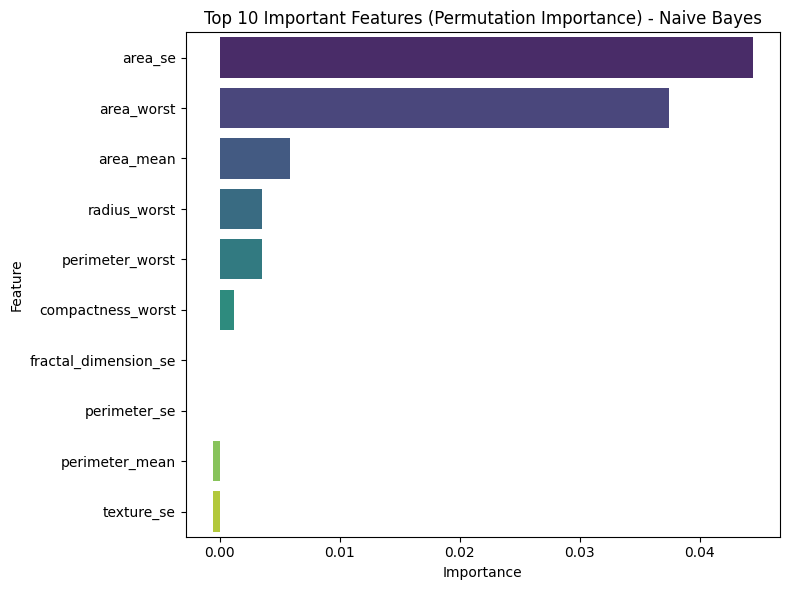

                 Feature    Importance
13               area_se  4.444444e-02
23            area_worst  3.742690e-02
3              area_mean  5.847953e-03
20          radius_worst  3.508772e-03
22       perimeter_worst  3.508772e-03
25     compactness_worst  1.169591e-03
19  fractal_dimension_se  0.000000e+00
12          perimeter_se -2.220446e-17
2         perimeter_mean -5.847953e-04
11            texture_se -5.847953e-04


In [ ]:
# Import `permutation_importance` to evaluate feature importance.
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the Naive Bayes model.
# This measures the decrease in model score when a feature's values are randomly shuffled.
perm_result = permutation_importance(nb_model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame of feature importance and sort it in descending order, showing the top 10 features.
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_result.importances_mean
}).sort_values("Importance", ascending=False).head(10)

# Visualize the top 10 important features using a bar plot.
plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df, hue="Feature", palette="viridis", legend=False)
plt.title("Top 10 Important Features (Permutation Importance) - Naive Bayes")
plt.tight_layout()
plt.show()

# Print the DataFrame of feature importance.
print(importance_df)

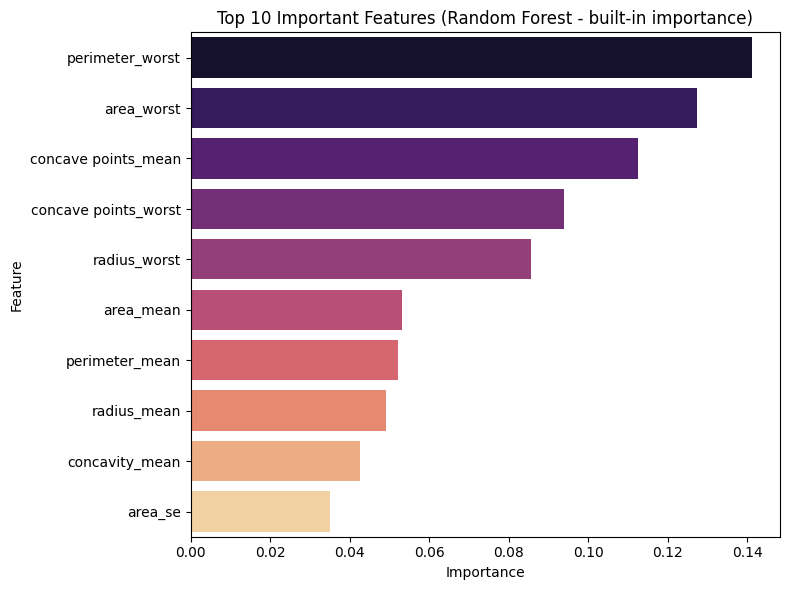

                 Feature  Importance
22       perimeter_worst    0.141211
23            area_worst    0.127340
7    concave points_mean    0.112583
27  concave points_worst    0.094050
20          radius_worst    0.085649
3              area_mean    0.053067
2         perimeter_mean    0.052225
0            radius_mean    0.049073
6         concavity_mean    0.042670
13               area_se    0.035200


In [ ]:
# Get the trained Random Forest model from the 'models' dictionary.
rf_model = models["Random Forest"]

# Calculate feature importance using the built-in `feature_importances_` attribute of the Random Forest model.
# Then create a DataFrame and sort it in descending order, displaying the top 10 features.
rf_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

# Create a figure and axes for the plot.
plt.figure(figsize=(8,6))
# Draw a bar plot of feature importance.
sns.barplot(x="Importance", y="Feature", data=rf_importance_df, hue="Feature", palette="magma", legend=False)
# Set the title of the plot.
plt.title("Top 10 Important Features (Random Forest - built-in importance)")
# Adjust the plot layout to prevent labels from overlapping.
plt.tight_layout()
# Display the plot.
plt.show()

# Print the DataFrame of feature importance.
print(rf_importance_df)